In [5]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
data = pd.read_csv("/content/Banking_Complaints.csv")

data.head()

,Complaint_ID,Complaint,Category
0,1,My credit card payment is showing as pending. ...,Credit Card
1,2,"Please help me, I have not received an update ...",Loan
2,3,I want to dispute a credit card charge. I woul...,Credit Card
3,4,I was charged twice for the same transaction. ...,Transaction
4,5,The interest rate on my loan appears to be inc...,Loan


In [8]:
print(data.shape)
print(data.columns)
print(data.isnull().sum())

(1000, 3)
Index(['Complaint_ID', 'Complaint', 'Category'], dtype='object')
Complaint_ID    0
Complaint       0
Category        0
dtype: int64


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [11]:
data['Clean_Complaint'] = data['Complaint'].apply(clean_text)

data[['Complaint', 'Clean_Complaint']].head()

,Complaint,Clean_Complaint
0,My credit card payment is showing as pending. ...,credit card payment showing pending kindly loo...
1,"Please help me, I have not received an update ...",please help received update loan application
2,I want to dispute a credit card charge. I woul...,want dispute credit card charge would apprecia...
3,I was charged twice for the same transaction. ...,charged twice transaction please resolve soon ...
4,The interest rate on my loan appears to be inc...,interest rate loan appears incorrect please re...


In [12]:
data['Category'].value_counts()

,count
Category,
Credit Card,160
Fraud,155
ATM,147
Account Management,137
Loan,136
Transaction,134
Online Banking,131


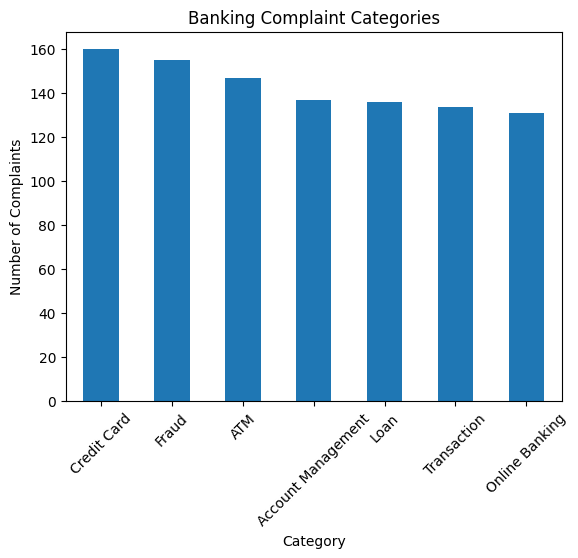

In [13]:
data['Category'].value_counts().plot(kind='bar')

plt.title("Banking Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.show()

In [14]:
tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(data['Clean_Complaint'])

words = tfidf.get_feature_names_out()

scores = X.toarray().sum(axis=0)

result = pd.DataFrame({
    'Word': words,
    'Score': scores
})

result = result.sort_values('Score', ascending=False)

result

,Word,Score
8,help,172.616619
14,please,159.329157
13,need,122.173912
6,concerned,121.204893
0,account,112.246123
19,would,108.905109
1,appreciate,108.905109
5,card,108.161064
2,assistance,107.654209
12,look,103.816733


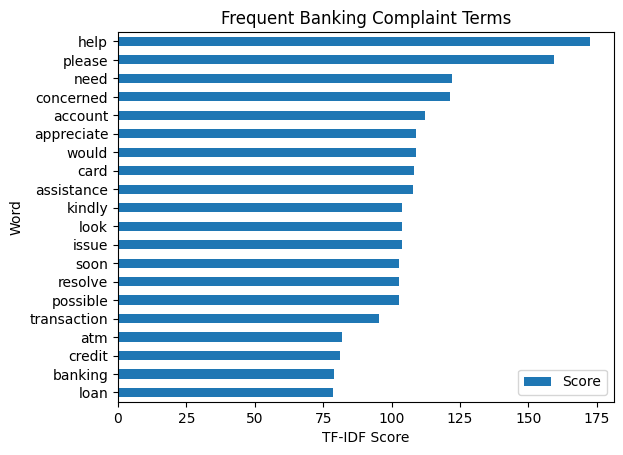

In [15]:
result.sort_values('Score').plot(
    x='Word',
    y='Score',
    kind='barh'
)

plt.title("Frequent Banking Complaint Terms")
plt.xlabel("TF-IDF Score")

plt.show()

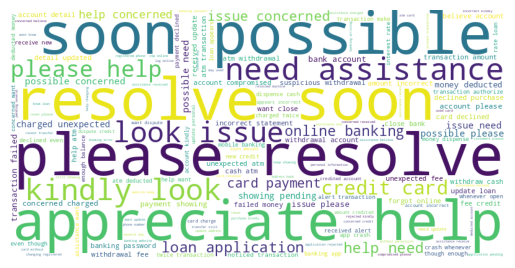

In [16]:
text = " ".join(data['Clean_Complaint'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [17]:
total = len(data)

print("Total Complaints:", total)

Total Complaints: 1000


In [18]:
most_common = data['Category'].value_counts().idxmax()

print("Most Common Complaint Category:", most_common)

Most Common Complaint Category: Credit Card


In [19]:
category_counts = data['Category'].value_counts()

print(category_counts)

Category
Credit Card           160
Fraud                 155
ATM                   147
Account Management    137
Loan                  136
Transaction           134
Online Banking        131
Name: count, dtype: int64


In [20]:
print("BANKING COMPLAINT ANALYSIS REPORT")

print("Total Complaints:", len(data))

print("Most Common Category:",
      data['Category'].value_counts().idxmax())

print("\nComplaints by Category:")

print(data['Category'].value_counts())

print("\nMost Frequent Terms:")

print(result.head(10))

BANKING COMPLAINT ANALYSIS REPORT
Total Complaints: 1000
Most Common Category: Credit Card

Complaints by Category:
Category
Credit Card           160
Fraud                 155
ATM                   147
Account Management    137
Loan                  136
Transaction           134
Online Banking        131
Name: count, dtype: int64

Most Frequent Terms:
          Word       Score
8         help  172.616619
14      please  159.329157
13        need  122.173912
6    concerned  121.204893
0      account  112.246123
19       would  108.905109
1   appreciate  108.905109
5         card  108.161064
2   assistance  107.654209
12        look  103.816733
